## Actividad 3_15: Uso de  para clasificación de clientes
<div style="border-style:groove;border-width:thin;padding:10px">
En este ejercicio vamos a utilizar KMeans para segmetar o clasificar a un grupo de clientes. En este caso se trata de los clientes de una empresa que vende una gran variedad de cosas. Vamos a utilizar un dataset de una campaña de márketing de una empresa que contiene datos de sus clientes. Estos datos son muy variados. Van desde la fecha de nacimiento hasta lo que han gastado en fruta pasando por el estado civil. 
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
1. Cargamos el dataset.
</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("marketing_campaign.csv",sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


<div style="border-style:groove;border-width:thin;padding:10px">
2. Borra la columna ID, ya que no nos aporta nada para segmentar los clientes. Cambia la Columna 'Year_Birth' por una con la edad de cada cliente. Pinta un gráfico de la distribución de edad. Puedes usar sns.violinplot para hacerlo. Consulta la documentación. Es una herramienta sencilla para pintar la distribución de una población por edad.
</div>

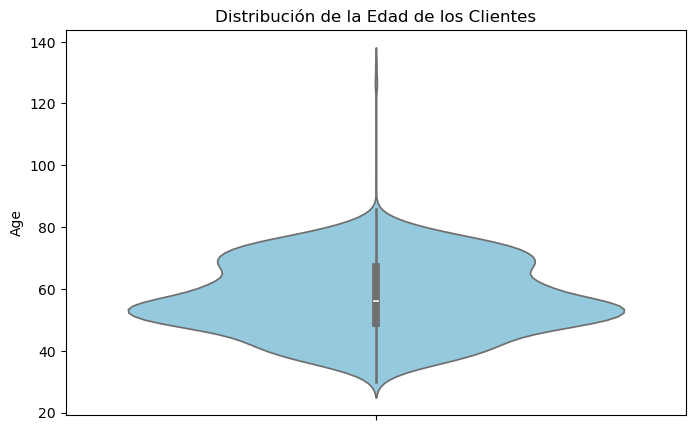

In [3]:
df = df.drop(columns=["ID"])

df['Age'] = 2026 - df['Year_Birth']

plt.figure(figsize=(8, 5))
sns.violinplot(y=df['Age'], color="skyblue")
plt.title("Distribución de la Edad de los Clientes")
plt.show()

In [4]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,0,0,0,0,0,0,3,11,1,69
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,0,0,0,0,0,0,3,11,0,72
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,0,0,0,0,0,0,3,11,0,61
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,0,0,0,0,0,0,3,11,0,42
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,0,0,0,0,0,0,3,11,0,45


In [5]:
df = df.drop(columns="Year_Birth")

<div style="border-style:groove;border-width:thin;padding:10px">
3. ¿Ves algo raro en la distribución? Elimina los datos que consideres que deben ser eliminados y vuelve a pintar la distribución por edad.
</div>

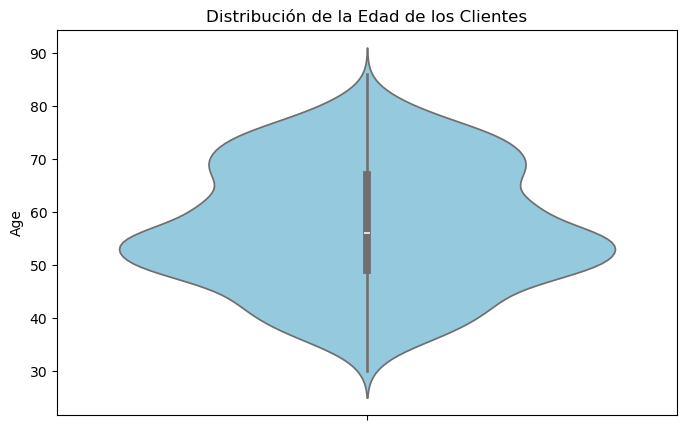

In [6]:
indices_a_borrar = df[df['Age'] > 90].index
df = df.drop(indices_a_borrar)

plt.figure(figsize=(8, 5))
sns.violinplot(y=df['Age'], color="skyblue")
plt.title("Distribución de la Edad de los Clientes")
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
4. Pinta un gráfico de barras (sns.barplot) con el número de individuos por nivel educativo. Puedes usar también  df.Education.value_counts().
</div>

<Axes: xlabel='Education'>

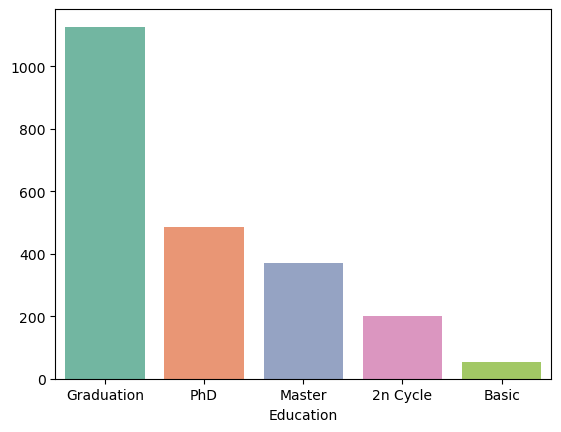

In [7]:
educations = df["Education"].value_counts()

sns.barplot(
    x=educations.index, 
    y=educations.values, 
    palette='Set2', 
    hue=educations.index, 
    legend=False
)

<div style="border-style:groove;border-width:thin;padding:10px">
5. Pinta ahora un gráfico de barras del sueldo medio por nivel educativo.
</div>

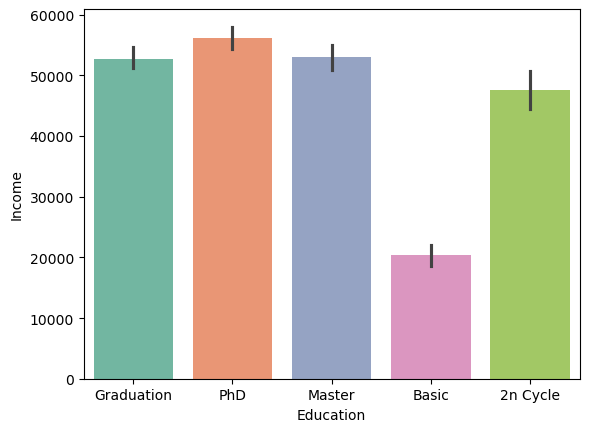

In [8]:
sns.barplot(x='Education', y='Income', data=df, palette='Set2', hue='Education')
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
6. Pinta un gráfico de barras del sueldo por tramos de edades de 20 en 20 años.
</div>

/tmp/ipykernel_4263/1327665754.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


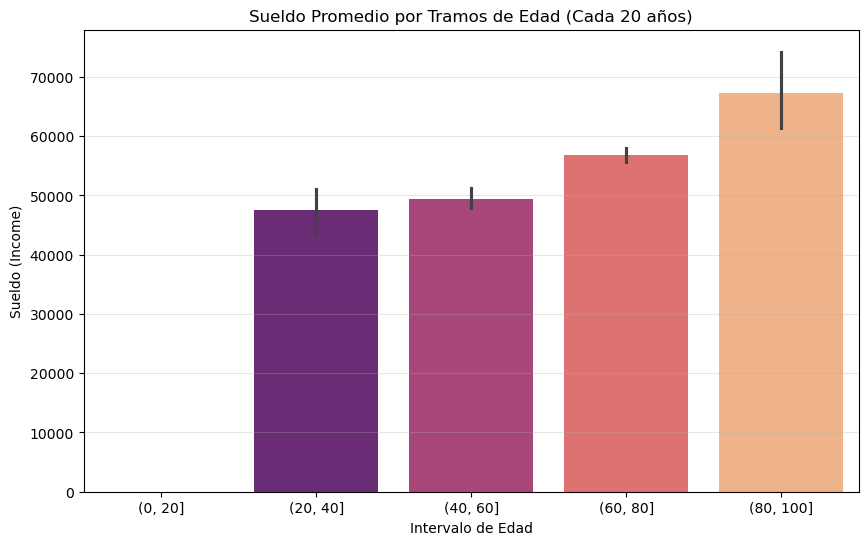

In [9]:
plt.figure(figsize=(10, 6))

# Graficamos calculando los tramos directamente en el eje X
sns.barplot(
    x=pd.cut(df['Age'], bins=[0, 20, 40, 60, 80, 100]), 
    y=df['Income'],
    palette='magma'
)

plt.title('Sueldo Promedio por Tramos de Edad (Cada 20 años)')
plt.xlabel('Intervalo de Edad')
plt.ylabel('Sueldo (Income)')
plt.grid(axis='y', alpha=0.3)
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
7. Cambia las columnas categóricas por valores numéricos (con el método que prefieras) y elimina los valores nulos (recuerda que se hace con dropna).
</div>

In [10]:
# Eliminamos cualquier fila que tenga valores nulos
df = df.dropna()

# Verificamos que ya no existan nulos
print(f"Valores nulos restantes: {df.isnull().sum().sum()}")

Valores nulos restantes: 0


In [11]:
df.describe(include=['object'])

,Education,Marital_Status,Dt_Customer
count,2213,2213,2213
unique,5,8,662
top,Graduation,Married,31-08-2012
freq,1116,857,12


<div style="border-style:groove;border-width:thin;padding:10px">
    <p>Ahora vamos a implementar el <b>METODO DEL CODO</b>. Este método consiste en hacer el método KMeans con distintos números de clusters (k). Después se calcula la suma de los Errores Cuadráticos Medios en cada Cluster (WCSS). Se pinta la gráfica de los WCSS para cada valor de k y te quedas con el valor del "codo", es decir, a partir del cual el WCSS baja bastante despacio.</p>
    <p>Los pasos serían los siguientes:</p>
    <ol>
        <li>Realiza el KMeans con valores de k de 0 a 10 o 15, por ejemplo.</li>
        <li>Guarda el dato kmeans.inertia_ para cada valor de k en una lista (este valor se corresponde con el WCSS)</li>
        <li>Pinta la lista de WCSS vs k.</li>
        <li>Busca el valor adecuado del "codo".</li>
    </ol>
</div>

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Eliminar columnas que no sirven para el modelo (como ID o fechas)
# Si no las has borrado, el scaler fallará con las fechas también
cols_a_borrar = ['ID', 'Dt_Customer']
for col in cols_a_borrar:
    if col in df.columns:
        df = df.drop(columns=[col])

# 2. Convertir las columnas de texto (Education y Marital_Status)
le = LabelEncoder()

# Lista de columnas que sabemos que son texto según tu imagen
columnas_texto = ['Education', 'Marital_Status']

for col in columnas_texto:
    if df[col].dtype == 'object': # Solo si todavía es texto
        df[col] = le.fit_transform(df[col])

# Eliminar nulos 
df = df.dropna()

# Escalar los datos
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)


<div style="border-style:groove;border-width:thin;padding:10px">
    <p>8. Implementa el método del codo con el dataset actual y anota el valor adecuado de k.</p>
</div>

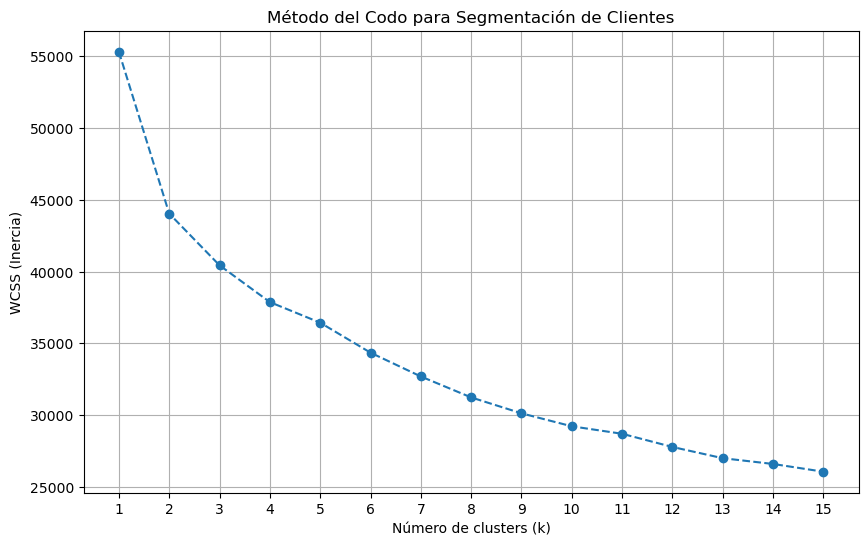

In [14]:
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 16)

for k in K_range:
    # init='k-means++' ayuda a una convergencia más rápida
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Método del Codo para Segmentación de Clientes')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (Inercia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
9. Ahora implementa KMeans con el número obtenido anteriomente y guarda las etiquetas en una columna nueva del dataframe.
</div>

In [15]:
from sklearn.cluster import KMeans

# 1. Definimos el número de clusters elegido (el "codo")
k_optimo = 4 

# 2. Inicializamos y entrenamos el modelo final
# Usamos random_state=42 para que los resultados sean siempre los mismos al ejecutar
kmeans_final = KMeans(n_clusters=k_optimo, init='k-means++', random_state=42, n_init=10)
clusters_predict = kmeans_final.fit_predict(df_scaled)

# 3. Guardamos las etiquetas en una columna nueva del dataframe original
# Importante: Asegúrate de usar el dataframe que no tiene nulos (el que usaste para el scaler)
df['Cluster'] = clusters_predict

# 4. Verificamos cuántos clientes han caído en cada grupo
print("Cantidad de clientes por cluster:")
print(df['Cluster'].value_counts())

# Mostramos las primeras filas con la nueva columna
df.head()

Cantidad de clientes por cluster:
Cluster
3    992
0    607
2    446
1    168
Name: count, dtype: int64


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Cluster
0,2,4,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,0,3,11,1,69,2
1,2,4,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,3,11,0,72,3
2,2,5,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,3,11,0,61,2
3,2,5,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,3,11,0,42,3
4,4,3,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,3,11,0,45,0


<div style="border-style:groove;border-width:thin;padding:10px">
10. Crea un dataframe nuevo con los datos del original pero quédate solo con las columnas que tienen valores significativos para nosotros. Vamos a ver si encontramos relaciones entre los clientes de un cluster (el 0, por ejemplo). Pinta los valores del dataframe (por ejemplo, el nivel educativo, el estado civil, los ingresos, el número total de hijos, el número total de gasto y la edad) de los individuos de la clase 0. ¿Identificas alguna relación?
</div>

In [16]:
# 1. Creamos las métricas calculadas que nos interesan
# Sumamos todos los gastos (Mnt...)
cols_gasto = [col for col in df.columns if 'Mnt' in col]
df['Total_Spent'] = df[cols_gasto].sum(axis=1)

# Sumamos hijos y adolescentes
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# 2. Creamos el nuevo dataframe con las columnas significativas
columnas_interes = [
    'Education', 'Marital_Status', 'Income', 
    'Total_Children', 'Total_Spent', 'Age', 'Cluster'
]
df_resumen = df[columnas_interes].copy()

# 3. Filtramos solo para el Cluster 0
cluster_0 = df_resumen[df_resumen['Cluster'] == 0]

print(f"Número de individuos en el Cluster 0: {len(cluster_0)}")
cluster_0.head()

Número de individuos en el Cluster 0: 607


,Education,Marital_Status,Income,Total_Children,Total_Spent,Age,Cluster
4,4,3,58293.0,1,422,45,0
5,3,5,62513.0,1,716,59,0
6,2,2,55635.0,1,590,55,0
13,3,2,59354.0,2,310,74,0
17,2,5,37760.0,0,317,80,0


/tmp/ipykernel_4263/165113530.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Education', data=cluster_0, ax=axes[0, 2], palette='viridis')
/tmp/ipykernel_4263/165113530.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Total_Children', data=cluster_0, ax=axes[1, 1], palette='magma')
/tmp/ipykernel_4263/165113530.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Marital_Status', data=cluster_0, ax=axes[1, 2], palette='rocket')


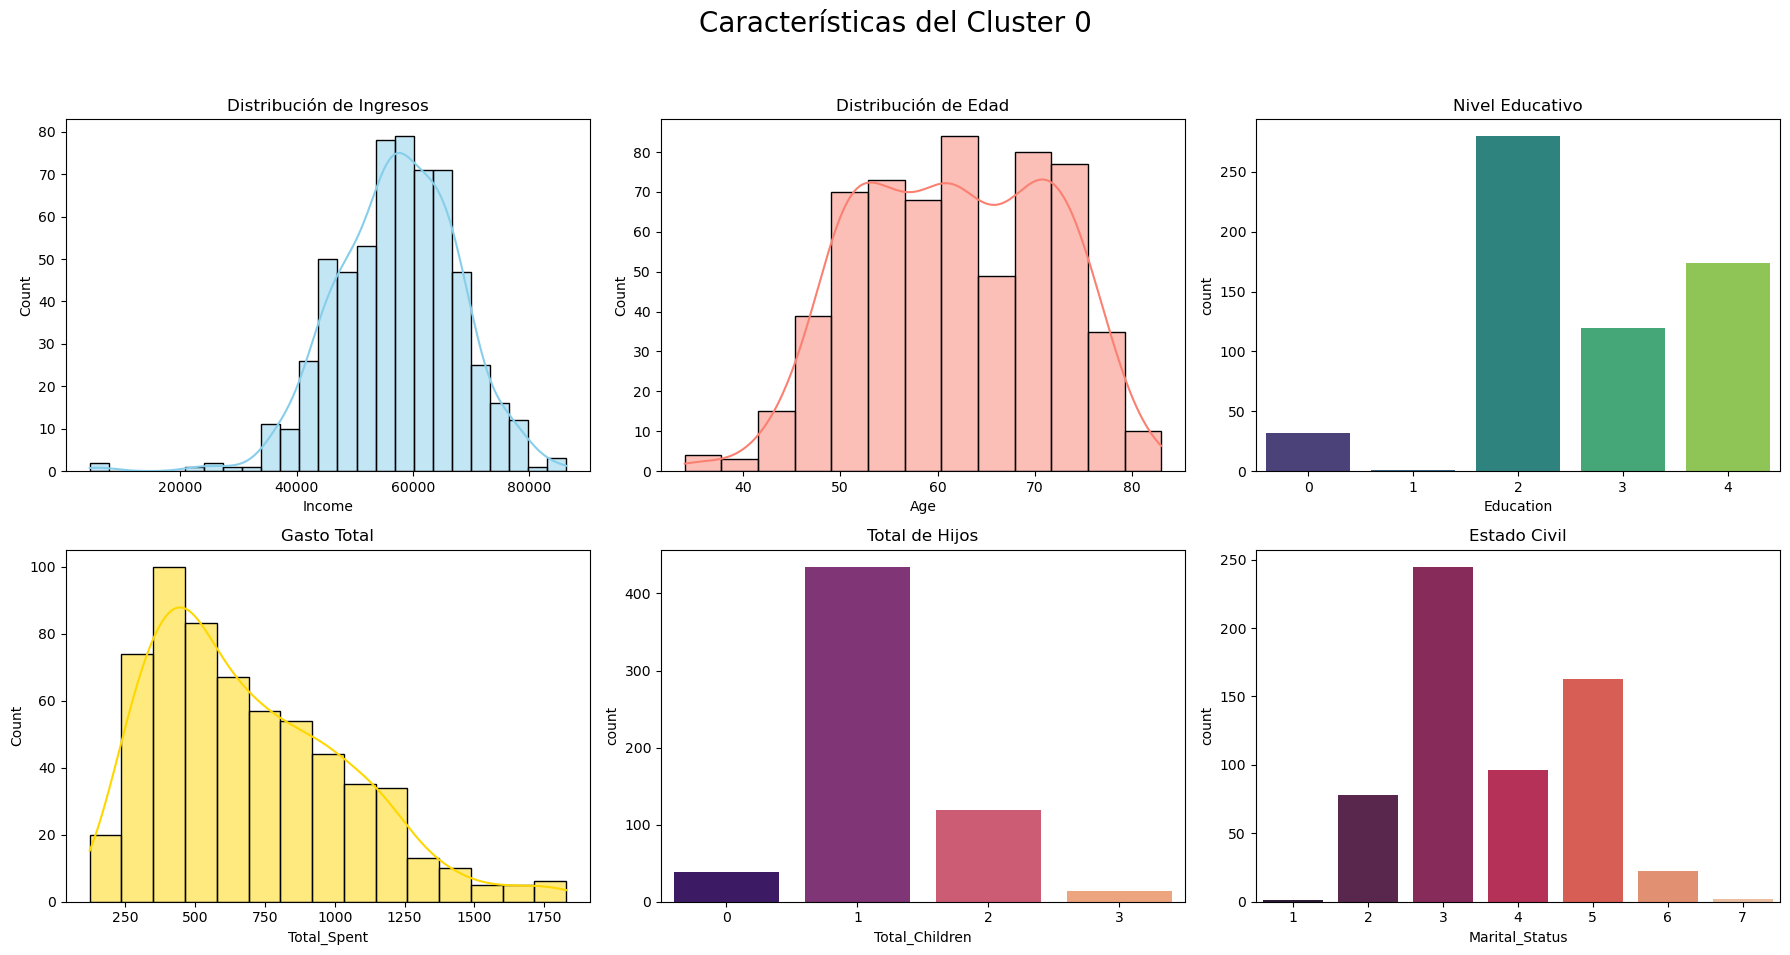

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Características del Cluster 0', fontsize=20)

# Ingresos
sns.histplot(cluster_0['Income'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de Ingresos')

# Edad
sns.histplot(cluster_0['Age'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribución de Edad')

# Nivel Educativo
sns.countplot(x='Education', data=cluster_0, ax=axes[0, 2], palette='viridis')
axes[0, 2].set_title('Nivel Educativo')

# Gasto Total
sns.histplot(cluster_0['Total_Spent'], kde=True, ax=axes[1, 0], color='gold')
axes[1, 0].set_title('Gasto Total')

# Número de Hijos
sns.countplot(x='Total_Children', data=cluster_0, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Total de Hijos')

# Estado Civil
sns.countplot(x='Marital_Status', data=cluster_0, ax=axes[1, 2], palette='rocket')
axes[1, 2].set_title('Estado Civil')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()